In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
inventory_df = pd.read_csv("../data/processed/inventory_classified.csv")

inventory_df.head()

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point,inventory_status,annual_consumptino_value,annual_consumption_value,cumulative_value,cumulative_percentage,ABC_Class,cv,XYZ_Class,ABC_XYZ
0,38,34.043478,34.133961,7.132127,1055,1831.211806,1,11.0,11.0,4.0,308,727,Optimal,2.281488e+07,2.281488e+07,2.281488e+07,6.107329,A,0.209501,X,AX
1,29,31.264214,31.293951,7.871904,494,1702.419699,5,5.0,5.0,2.0,128,304,Overstock,1.944554e+07,1.944554e+07,4.226041e+07,11.312717,A,0.251786,Y,AY
2,24,23.277592,23.430942,5.488842,776,2119.237224,2,10.0,10.0,2.0,322,593,Optimal,1.812434e+07,1.812434e+07,6.038475e+07,16.164434,A,0.235799,X,AX
3,39,29.729097,30.079778,5.737273,438,1638.972642,7,5.0,5.0,4.0,173,341,Optimal,1.799448e+07,1.799448e+07,7.837923e+07,20.981387,A,0.192985,X,AX
4,12,37.518395,37.570501,6.278398,710,1206.858395,8,7.0,7.0,4.0,352,641,Optimal,1.654993e+07,1.654993e+07,9.492916e+07,25.411648,A,0.167342,X,AX


In [3]:
inventory_df["calculated_safety_stock"] = (
    1.65 *
    inventory_df["demand_std"] *
    np.sqrt(inventory_df["lead_time_days"])
)

inventory_df[
    [
        "safety_stock",
        "calculated_safety_stock"
    ]
].head()

,safety_stock,calculated_safety_stock
0,308,39.030070
1,128,29.043485
2,322,28.639448
3,173,21.167737
4,352,27.408283


REorder point

In [4]:
inventory_df['calculated_reorder_point'] = (
    inventory_df['avg_predicted_demand']*
    inventory_df['lead_time_days']+
    inventory_df['calculated_safety_stock']
)

EOQ

In [5]:
ordering_cost = 500
holding_cost_rate =0.20

In [6]:
inventory_df['holding_cost'] =(
    inventory_df['selling_price']*
    holding_cost_rate
)

In [7]:
inventory_df["annual_demand"] = (

    inventory_df["avg_predicted_demand"]

    *

    365

)

In [8]:
inventory_df['EOQ'] = np.sqrt(
    (2*inventory_df['annual_demand']*
    ordering_cost)/ inventory_df['holding_cost']
)

Days of Inventory

In [9]:
inventory_df["days_of_inventory"] = (

    inventory_df["current_stock"]

    /

    inventory_df["avg_predicted_demand"]

)

Inventory Gap

In [10]:
inventory_df["inventory_gap"] = (

    inventory_df["current_stock"]

    -

    inventory_df["calculated_reorder_point"]

)

Inventory status


In [12]:
conditions = [

    inventory_df["current_stock"] <
    inventory_df["calculated_reorder_point"],

    inventory_df["current_stock"] >
    inventory_df["EOQ"] * 2

]

choices = ["Reorder", "Overstock"]

inventory_df["inventory_status"] = np.select(conditions,choices ,default="Optimal")

# Risk Score

In [14]:
inventory_df['risk_score'] = (inventory_df['demand_std'] * inventory_df['lead_time_variability'])

# Risk Category

In [15]:
inventory_df['risk_level'] = pd.qcut(inventory_df['risk_score'], q=3, labels = ['Low' , 'Medium','High'])

# Final Recommendation

In [16]:
def inventory_action(row):

    if row['inventory_status'] == 'Reorder':
        return 'Order Immediately'

    elif row["inventory_status"] == "Overstock":
        return "Reduce Inventory"

    else:
        return "Maintain Current Stock"

    

inventory_df['recommendation'] = (
    inventory_df.apply(inventory_action , axis =1)
)

In [17]:
inventory_df["inventory_status"].value_counts()


inventory_status
Overstock    22
Optimal      18
Name: count, dtype: int64

In [18]:
inventory_df["recommendation"].value_counts()

recommendation
Reduce Inventory          22
Maintain Current Stock    18
Name: count, dtype: int64

In [19]:
inventory_df["risk_level"].value_counts()

risk_level
High      14
Low       13
Medium    13
Name: count, dtype: int64

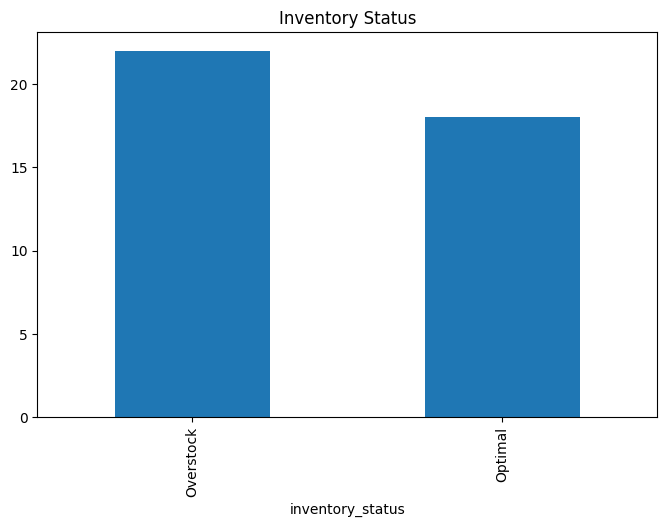

In [20]:
inventory_df["inventory_status"].value_counts().plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Inventory Status")

plt.show()


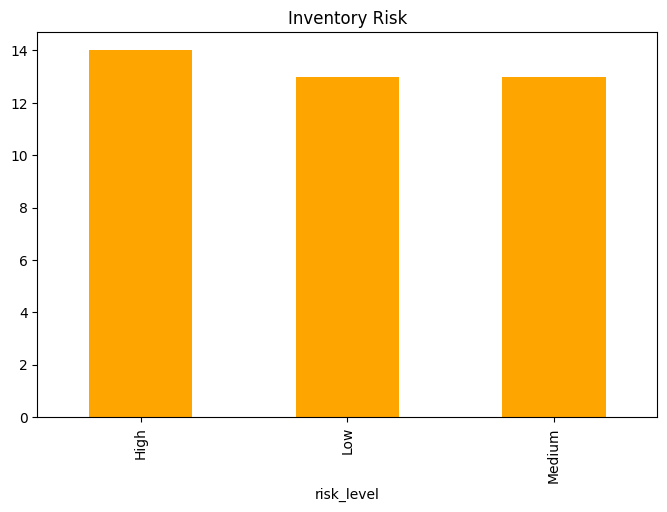

In [21]:
inventory_df["risk_level"].value_counts().plot(

    kind="bar",

    figsize=(8,5),

    color="orange"

)

plt.title("Inventory Risk")

plt.show()

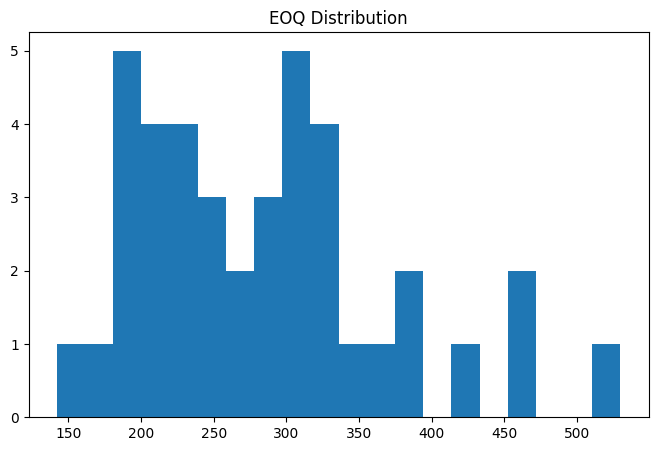

In [22]:
plt.figure(figsize=(8,5))

plt.hist(

    inventory_df["EOQ"],

    bins=20

)

plt.title("EOQ Distribution")

plt.show()

Days of inventory

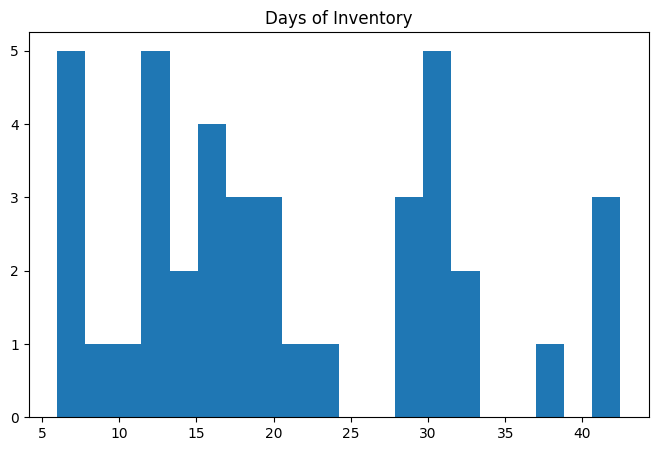

In [24]:
plt.figure(figsize=(8,5))

plt.hist(

    inventory_df["days_of_inventory"],

    bins=20

)

plt.title("Days of Inventory")

plt.show()

In [25]:
inventory_df.to_csv(

    "../data/processed/final_inventory_recommendation.csv",

    index=False

)